In [17]:
 # prompt: move the folder in the path varable to the content/

import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

# Define the destination folder
destination_folder = "/content/"

# Get the folder name from the downloaded path
folder_name = os.path.basename(path)

# Create the full destination path
destination_path = os.path.join(destination_folder, folder_name)


# Move the folder
try:
    shutil.move(path, destination_path)
    print(f"Folder '{folder_name}' moved to '{destination_path}'")
except Exception as e:
    print(f"Error moving folder: {e}")


print("New Path to dataset files:", destination_path)


Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Error moving folder: Destination path '/content/consumer-reviews-of-amazon-products/consumer-reviews-of-amazon-products' already exists
New Path to dataset files: /content/consumer-reviews-of-amazon-products


In [19]:
import pandas as pd
df = pd.read_csv('/content/consumer-reviews-of-amazon-products/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')

In [ ]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

In [20]:
# Select only the required columns
df_selected = df[['reviews.title', 'reviews.rating', 'reviews.text']].copy()

# Create a new column for sentiment
def get_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:  # 4 or 5
        return 'positive'

df_selected['sentiment'] = df_selected['reviews.rating'].apply(get_sentiment)


In [21]:
df_selected.columns

Index(['reviews.title', 'reviews.rating', 'reviews.text', 'sentiment'], dtype='object')

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Missing values in each column:
reviews.title     13
reviews.rating     0
reviews.text       0
sentiment          0
dtype: int64


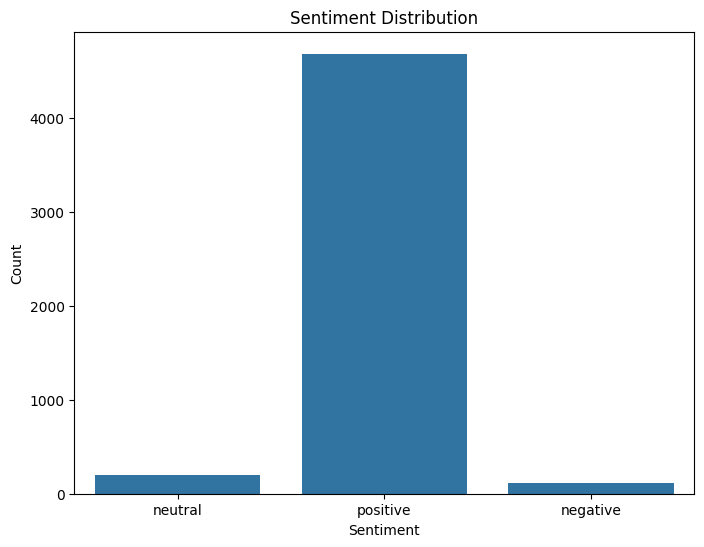

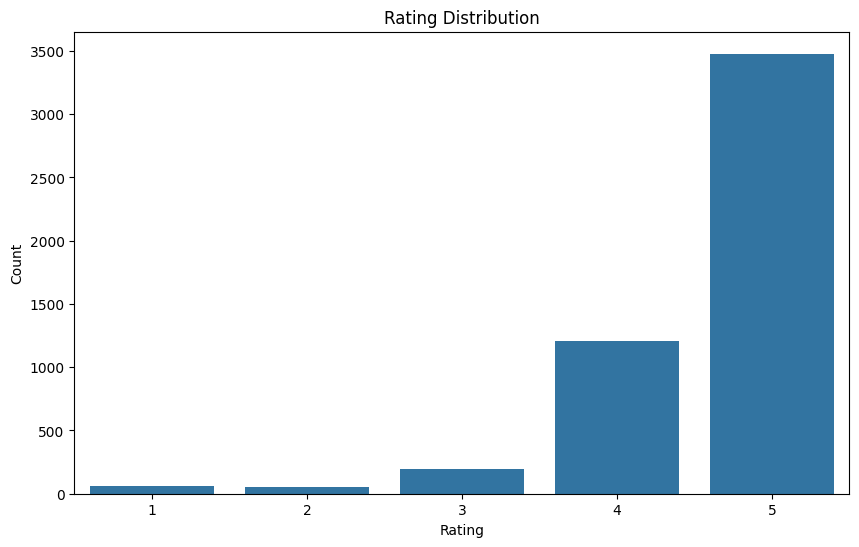

In [23]:
# Check for missing values
print("Missing values in each column:")
print(df_selected.isnull().sum())

# Fill missing values if any
df_selected['reviews.text'] = df_selected['reviews.text'].fillna('')
df_selected['reviews.title'] = df_selected['reviews.title'].fillna('')

# Visualize sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df_selected)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('sentiment_distribution.png')
plt.show()
plt.close()

# Visualize rating distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='reviews.rating', data=df_selected)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('rating_distribution.png')
plt.show()
plt.close()

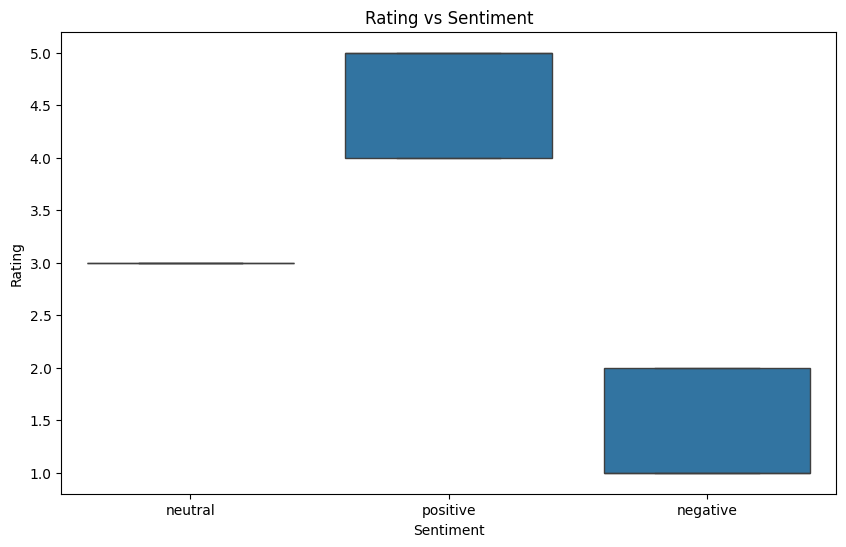

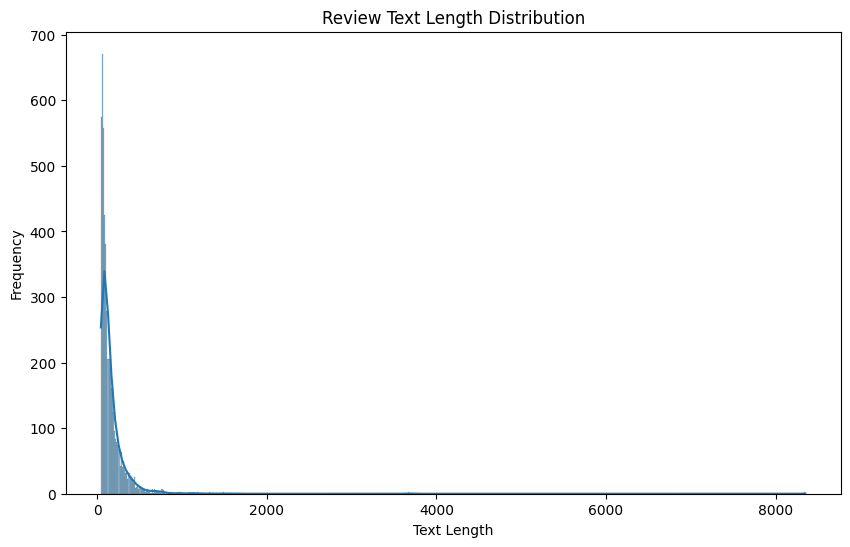

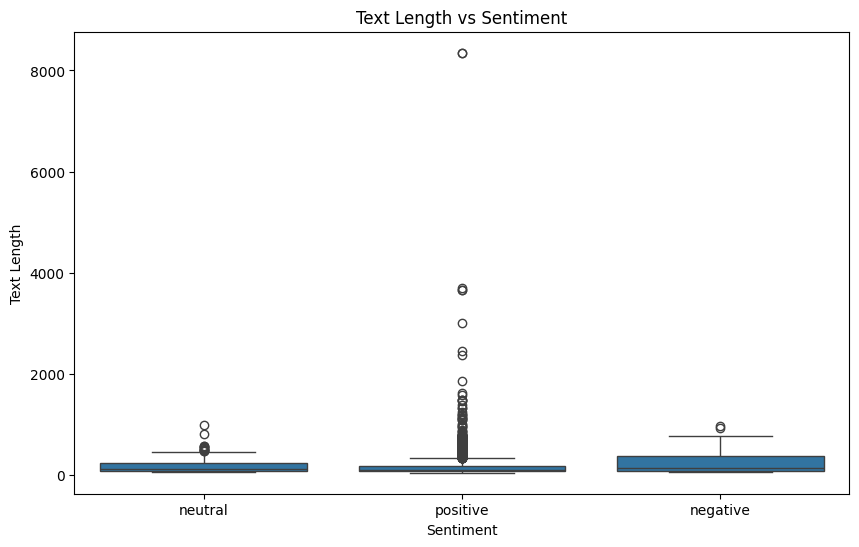

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='reviews.rating', data=df_selected)
plt.title('Rating vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Rating')
plt.savefig('rating_vs_sentiment.png')
plt.show()
plt.close()

# Text length analysis
df_selected['text_length'] = df_selected['reviews.text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df_selected['text_length'], kde=True)
plt.title('Review Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.savefig('text_length_distribution.png')
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='text_length', data=df_selected)
plt.title('Text Length vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Text Length')
plt.savefig('text_length_vs_sentiment.png')
plt.show()
plt.close()

In [25]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove special characters and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

# Apply preprocessing to title and text
df_selected['processed_title'] = df_selected['reviews.title'].apply(preprocess_text)
df_selected['processed_text'] = df_selected['reviews.text'].apply(preprocess_text)

# Combine title and text for a richer feature set
df_selected['processed_combined'] = df_selected['processed_title'] + ' ' + df_selected['processed_text']

# 3. Feature Engineering
# ----------------------

# Create a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Split the dataset
X = df_selected['processed_combined']
y = df_selected['sentiment']


# part two -----------------------------

In [26]:
# Install required libraries
!pip install transformers datasets torch pandas numpy scikit-learn matplotlib seaborn gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [28]:
# Part 1: Setup and Data Preprocessing
# Run this cell first to set up the environment


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.cluster import KMeans
from transformers import pipeline
import gradio as gr

# Load dataset (assuming you’ve uploaded it to Colab)
# Download from: https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products
# Upload the CSV to Colab or mount Google Drive
# Load datasets
df = pd.read_csv('/content/consumer-reviews-of-amazon-products/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')
df2 = pd.read_csv('/content/consumer-reviews-of-amazon-products/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')

# Preprocess individual DataFrames
df2 = df2[['reviews.text', 'reviews.rating', 'name']].dropna()
df = df[['reviews.text', 'reviews.rating', 'name']].dropna()

# Remove positive reviews from df2 only
df2 = df2[df2['reviews.rating'] <= 3]

# Concatenate df (all reviews) and df2 (only neg + neutral)
df = pd.concat([df, df2], ignore_index=True)

# Sentiment mapping and encoding (same as before)
def map_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['reviews.rating'].apply(map_sentiment)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Split dataset
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Save preprocessed data
train_df.to_csv('/content/train.csv', index=False)
test_df.to_csv('/content/test.csv', index=False)

print("Data preprocessing complete. Train and test sets saved.")
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")


Data preprocessing complete. Train and test sets saved.
Train size: 24895, Test size: 6224


In [30]:
print(df['sentiment'].value_counts())

sentiment
positive    25545
negative     3162
neutral      2412
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: asem547 (asem547-cairo-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.162400,0.201191,0.938303,0.936676,0.938303,0.937279
2,0.103000,0.147618,0.964010,0.964299,0.964010,0.964146
3,0.063800,0.136697,0.971401,0.970948,0.971401,0.971108


Evaluation Results:
eval_loss: 0.1367
eval_accuracy: 0.9714
eval_precision: 0.9709
eval_recall: 0.9714
eval_f1: 0.9711
eval_runtime: 22.8994
eval_samples_per_second: 271.7970
eval_steps_per_second: 16.9870
epoch: 3.0000


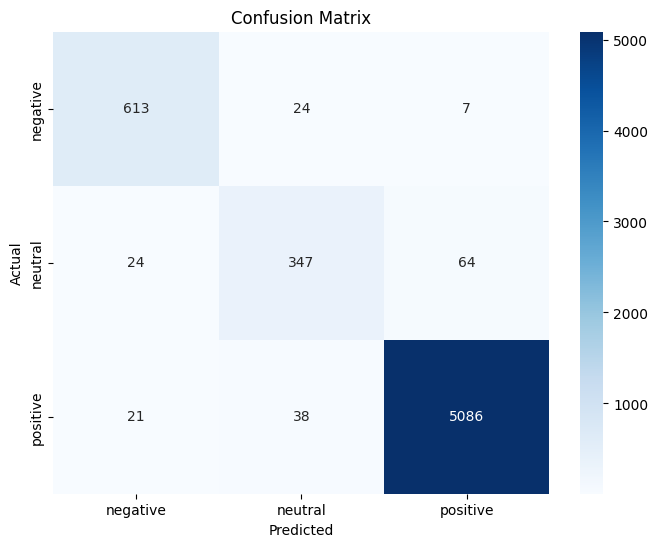

Classification model trained and saved.


In [31]:
# Part 2: Review Classification
# Run after Part 1

# Load preprocessed data
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['reviews.text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['reviews.text', 'label']])

# Load tokenizer and model
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples['reviews.text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Define compute metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Training arguments
training_args = TrainingArguments(
    output_dir='/content/results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='/content/logs',
    logging_steps=10,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train model
trainer.train()

# Evaluate model
eval_results = trainer.evaluate()

# Print results
print("Evaluation Results:")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# Plot confusion matrix
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Save model
model.save_pretrained('/content/classification_model')
tokenizer.save_pretrained('/content/classification_model')

print("Classification model trained and saved.")

,reviews.text,reviews.rating,name,sentiment,label
0,"This is our second Show. And, one of several C...",5,Amazon Echo Show Alexa-enabled Bluetooth Speak...,positive,2
1,I love our Amazon echo plus! My boyfriend says...,5,Amazon - Echo Plus w/ Built-In Hub - Silver,positive,2
2,I bought this a first tablet. I'm disappointed...,3,"Fire Tablet with Alexa, 7 Display, 16 GB, Mage...",neutral,1
3,My kids love their amazon kindles! They can ta...,5,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",positive,2
4,Batteries don't last long at all.,3,AmazonBasics AAA Performance Alkaline Batterie...,neutral,1
...,...,...,...,...,...
6224,They lasted less than 24 hours in my mouse and...,1,AmazonBasics AAA Performance Alkaline Batterie...,negative,0
6225,I purchased a box of these. First replacement ...,2,AmazonBasics AAA Performance Alkaline Batterie...,negative,0
6226,Great for video calling grandparents who are n...,4,Amazon Echo Show Alexa-enabled Bluetooth Speak...,positive,2
6227,It was ok. You need Internet. The SDmini is a ...,3,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",neutral,1


In [32]:
df = pd.read_csv('/content/consumer-reviews-of-amazon-products/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

In [33]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load preprocessed data
df = pd.read_csv('/content/consumer-reviews-of-amazon-products/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')
df2 = pd.read_csv('/content/consumer-reviews-of-amazon-products/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv')

# Preprocess individual DataFrames
df2 = df2[['reviews.text', 'reviews.rating', 'name']].dropna()
df = df[['reviews.text', 'reviews.rating', 'name']].dropna()

# Remove positive reviews from df2 only
df2 = df2[df2['reviews.rating'] <= 3]

# Load model for embeddings
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')

# Function to get embeddings
def get_embeddings(texts, batch_size=32):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            outputs = model(**inputs)
        # Use [CLS] token embedding
        batch_embeddings = outputs.last_hidden_state[:, 0, :].numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

# Combine features for clustering
def prepare_clustering_data(df):
    # Create combined text feature
    combined_features = df.apply(
        lambda row: f"{row['name']} {row['reviews.text']} rating:{row['reviews.rating']}",
        axis=1
    ).tolist()
    return combined_features

# Get embeddings for combined features
combined_features = prepare_clustering_data(df)
embeddings = get_embeddings(combined_features)

# Cluster products
n_clusters = 5  # Adjust between 4-6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# Create cluster mapping
df['cluster'] = cluster_labels

# Save clustered data
df.to_csv('/content/clustered_data.csv', index=False)

# Analyze clusters
cluster_counts = df['cluster'].value_counts()
print("Cluster Distribution:")
print(cluster_counts)

# Sample products per cluster
for cluster in range(n_clusters):
    print(f"\nCluster {cluster}:")
    cluster_products = df[df['cluster'] == cluster]['name'].unique()[:5]
    print(cluster_products)

print("Clustering complete. Clustered data saved.")

Cluster Distribution:
cluster
0    1199
3    1190
4    1118
1     830
2     663
Name: count, dtype: int64

Cluster 0:
['Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)'
 'Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen'
 'Amazon - Echo Plus w/ Built-In Hub - Silver'
 'Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders'
 'Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case']

Cluster 1:
['Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)'
 'Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen'
 'Amazon - Echo Plus w/ Built-In Hub - Silver'
 'Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders'
 'Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case']

Cluster 2:
['Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)'
 'Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen'
 'Amazon Fire TV with 4K Ultra HD an

In [34]:
# Part 4: Review Summarization
# Run after Part 3

# Load clustered data
df = pd.read_csv('/content/clustered_data.csv')
dft = pd.read_csv('/content/train.csv')

df = pd.concat([df, dft[['sentiment', 'label']]])

# Load summarization model
summarizer = pipeline('summarization', model='facebook/bart-large-cnn')

# Function to generate recommendation article
def generate_article(cluster_id, cluster_df):
    # Get top 3 products by average rating
    product_ratings = cluster_df.groupby('name')['reviews.rating'].mean().sort_values(ascending=False)
    top_products = product_ratings.head(3).index.tolist()

    # Get worst product
    worst_product = product_ratings.tail(1).index[0]

    # Collect reviews for top products
    article = f"Recommendations for Cluster {cluster_id}:\n\n"

    for product in top_products:
        product_reviews = cluster_df[cluster_df['name'] == product]['reviews.text'].tolist()
        positive_reviews = [r for r in product_reviews if cluster_df[cluster_df['reviews.text'] == r]['sentiment'].iloc[0] == 'positive']
        negative_reviews = [r for r in product_reviews if cluster_df[cluster_df['reviews.text'] == r]['sentiment'].iloc[0] == 'negative']

        # Summarize positive and negative reviews
        pos_summary = summarizer(' '.join(positive_reviews[:5]), max_length=50, min_length=25, do_sample=False)[0]['summary_text'] if positive_reviews else "No positive reviews."
        neg_summary = summarizer(' '.join(negative_reviews[:5]), max_length=50, min_length=25, do_sample=False)[0]['summary_text'] if negative_reviews else "No negative reviews."

        article += f"Product: {product}\n"
        article += f"Key Strengths: {pos_summary}\n"
        article += f"Top Complaints: {neg_summary}\n\n"

    # Summarize worst product
    worst_reviews = cluster_df[cluster_df['name'] == worst_product]['reviews.text'].tolist()
    worst_summary = summarizer(' '.join(worst_reviews[:5]), max_length=50, min_length=25, do_sample=False)[0]['summary_text'] if worst_reviews else "No reviews."
    article += f"Worst Product: {worst_product}\n"
    article += f"Why to Avoid: {worst_summary}\n"

    return article

# Generate articles for each cluster
articles = []
n_clusters = df['cluster'].nunique()
for cluster_id in range(n_clusters):
    cluster_df = df[df['cluster'] == cluster_id]
    article = generate_article(cluster_id, cluster_df)
    articles.append(article)
    print(f"\n{article}")

# Save articles
with open('/content/recommendations.txt', 'w') as f:
    f.write('\n\n'.join(articles))

print("Summarization complete. Articles saved to recommendations.txt.")

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Your max_length is set to 50, but your input_length is only 23. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=11)



Recommendations for Cluster 0:

Product: Kindle Oasis E-reader with Leather Charging Cover - Black, 6" High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Product: Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Product: Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Worst Product: Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders
Why to Avoid: Great price and ready to have it on hand. pretty convenient to have another cable to charge the kindle.


Recommendations for Cluster 1:

Product: Amazon - Echo Plus w/ Built-In Hub - Silver
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Product: Kin

Your max_length is set to 50, but your input_length is only 14. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)



Recommendations for Cluster 2:

Product: Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Product: Amazon Fire TV with 4K Ultra HD and Alexa Voice Remote (Pendant Design) | Streaming Media Player
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Product: Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)
Key Strengths: No positive reviews.
Top Complaints: No negative reviews.

Worst Product: Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker
Why to Avoid: This is one of the best products we have every purchased. Plays any songs, give directions, weather and the sound quality is EXCELLENT! This is great for the beach or by the pool. Not very informative.


Recommendations for Cluster 3:

Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue
Key Strengths: No positive reviews.
Top Complaints: No

In [35]:
# Part 5: Web App Deployment
# Run after Parts 2, 3, and 4

# Load models
classification_model = AutoModelForSequenceClassification.from_pretrained('/content/classification_model')
classification_tokenizer = AutoTokenizer.from_pretrained('/content/classification_model')
summarizer = pipeline('summarization', model='facebook/bart-large-cnn')

# Load clustered data and articles
df = pd.read_csv('/content/clustered_data.csv')
with open('/content/recommendations.txt', 'r') as f:
    articles = f.read().split('\n\nRecommendations for Cluster')

# Classification function
def classify_review(review_text):
    inputs = classification_tokenizer(review_text, return_tensors='pt', padding=True, truncation=True, max_length=128)
    outputs = classification_model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    return label_encoder.inverse_transform([pred])[0]

# Clustering function (simplified for demo)
def get_product_cluster(product_name):
    product_names = df['name'].unique()
    if product_name in product_names:
        cluster = df[df['name'] == product_name]['cluster'].iloc[0]
        return f"Cluster {cluster}"
    return "Product not found."

# Interface function
def web_app(review_text, product_name, cluster_id):
    # Classification
    sentiment = classify_review(review_text) if review_text else "No review provided."

    # Clustering
    cluster = get_product_cluster(product_name) if product_name else "No product provided."

    # Summarization
    article = articles[int(cluster_id)] if cluster_id and 0 <= int(cluster_id) < len(articles) else "Invalid cluster ID."

    return {
        "Sentiment": sentiment,
        "Product Cluster": cluster,
        "Recommendation Article": article
    }

# Create Gradio interface
iface = gr.Interface(
    fn=web_app,
    inputs=[
        gr.Textbox(label="Enter Review Text"),
        gr.Textbox(label="Enter Product Name"),
        gr.Number(label="Enter Cluster ID (0-4)")
    ],
    outputs=gr.JSON(),
    title="NLP Product Review System",
    description="Classify reviews, find product clusters, and view recommendations."
)

# Launch interface
iface.launch(share=True)  # Use share=False for local testing

print("Web app launched. Access the link provided by Gradio.")

Device set to use cuda:0


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f860946732bd881ae0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Web app launched. Access the link provided by Gradio.
